Reviewing The Data

In [7]:
import pandas as pd

df = pd.read_csv("../data/bmw_global_sales_dataset.csv")
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1000 non-null   int64  
 1   month                  1000 non-null   int64  
 2   country                1000 non-null   str    
 3   model                  1000 non-null   str    
 4   segment                1000 non-null   str    
 5   engine_type            1000 non-null   str    
 6   price_usd              1000 non-null   int64  
 7   marketing_spend_usd    1000 non-null   int64  
 8   dealership_count       1000 non-null   int64  
 9   fuel_price_usd         1000 non-null   float64
 10  gdp_growth_percent     1000 non-null   float64
 11  interest_rate_percent  1000 non-null   float64
 12  competition_index      1000 non-null   int64  
 13  units_sold             1000 non-null   int64  
dtypes: float64(3), int64(7), str(4)
memory usage: 130.2 KB


,year,month,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000
mean,2019.448000,6.487000,76535.747000,279492.230000,200.230000,9.700000e-01,6.290000e+00,1.200000e+00,5.572000,633.192000
std,2.912005,3.510863,25360.933749,127010.559722,113.096127,2.221557e-16,1.777246e-15,4.443114e-16,2.944059,263.346628
min,2015.000000,1.000000,35060.000000,50363.000000,10.000000,9.700000e-01,6.290000e+00,1.200000e+00,1.000000,15.000000
25%,2017.000000,3.000000,54578.750000,173552.250000,101.750000,9.700000e-01,6.290000e+00,1.200000e+00,3.000000,432.750000
50%,2019.000000,7.000000,75726.000000,278733.500000,197.000000,9.700000e-01,6.290000e+00,1.200000e+00,6.000000,630.000000
75%,2022.000000,10.000000,98730.250000,390110.000000,297.000000,9.700000e-01,6.290000e+00,1.200000e+00,8.000000,842.500000
max,2024.000000,12.000000,119817.000000,498927.000000,399.000000,9.700000e-01,6.290000e+00,1.200000e+00,10.000000,1242.000000


Fixing missing Values

In [57]:
# check data
print(df.info())
print(df.isnull().sum())

# remove duplicates
df = df.drop_duplicates()
df.dropna()

# create a date-like feature
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))


df.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1000 non-null   int64  
 1   month                  1000 non-null   int64  
 2   country                1000 non-null   str    
 3   model                  1000 non-null   str    
 4   segment                1000 non-null   str    
 5   engine_type            1000 non-null   str    
 6   price_usd              1000 non-null   int64  
 7   marketing_spend_usd    1000 non-null   int64  
 8   dealership_count       1000 non-null   int64  
 9   fuel_price_usd         1000 non-null   float64
 10  gdp_growth_percent     1000 non-null   float64
 11  interest_rate_percent  1000 non-null   float64
 12  competition_index      1000 non-null   int64  
 13  units_sold             1000 non-null   int64  
dtypes: float64(3), int64(7), str(4)
memory usage: 130.2 KB
None
year    

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold,date
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324,2021-01-01
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556,2018-08-01
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152,2022-12-01


In [58]:
# total revenue (VERY IMPORTANT feature)
df['revenue'] = df['units_sold'] * df['price_usd']

# categorize months (for seasonality insight)
df['quarter'] = pd.PeriodIndex(df['date'], freq='Q')

df.head(5).sort_values(by='date')  

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold,date,revenue,quarter
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556,2018-08-01,45753796,2018Q3
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,0.97,6.29,1.2,5,730,2019-11-01,30930830,2019Q4
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324,2021-01-01,26643816,2021Q1
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,0.97,6.29,1.2,2,1156,2021-12-01,95156140,2021Q4
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152,2022-12-01,6170288,2022Q4


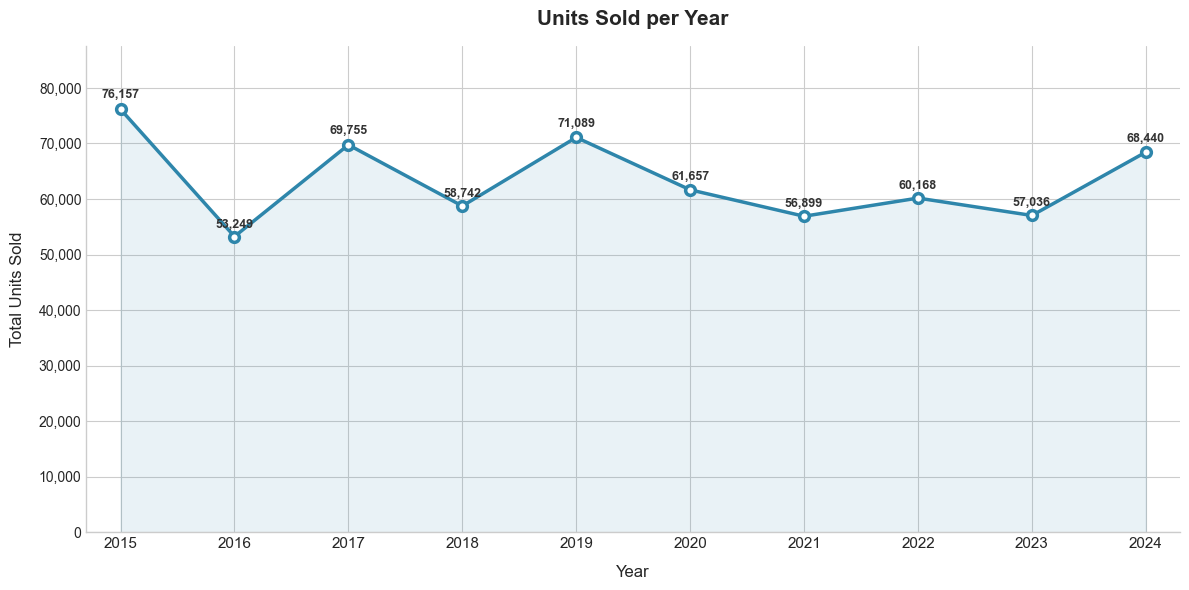

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Data ---
yearly_sales = df.groupby("year")["units_sold"].sum().sort_index()

# --- Style ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

# --- Line & fill ---
ax.plot(
    yearly_sales.index, yearly_sales.values,
    color="#2E86AB", linewidth=2.5, marker="o",
    markersize=7, markerfacecolor="white", markeredgewidth=2.5
)
ax.fill_between(yearly_sales.index, yearly_sales.values, alpha=0.1, color="#2E86AB")

# --- Value labels on each point ---
for x, y in zip(yearly_sales.index, yearly_sales.values):
    ax.text(
        x, y * 1.02,
        f"{y:,}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color="#333333"
    )

# --- Axis formatting ---
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f"{val:,.0f}"))
ax.set_xlim(yearly_sales.index.min() - 0.3, yearly_sales.index.max() + 0.3)
ax.set_ylim(0, yearly_sales.values.max() * 1.15)
ax.set_xticks(yearly_sales.index)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=10)

# --- Labels & title ---
ax.set_title("Units Sold per Year", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=12, labelpad=10)
ax.set_ylabel("Total Units Sold", fontsize=12, labelpad=10)

# --- Clean up spines ---
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

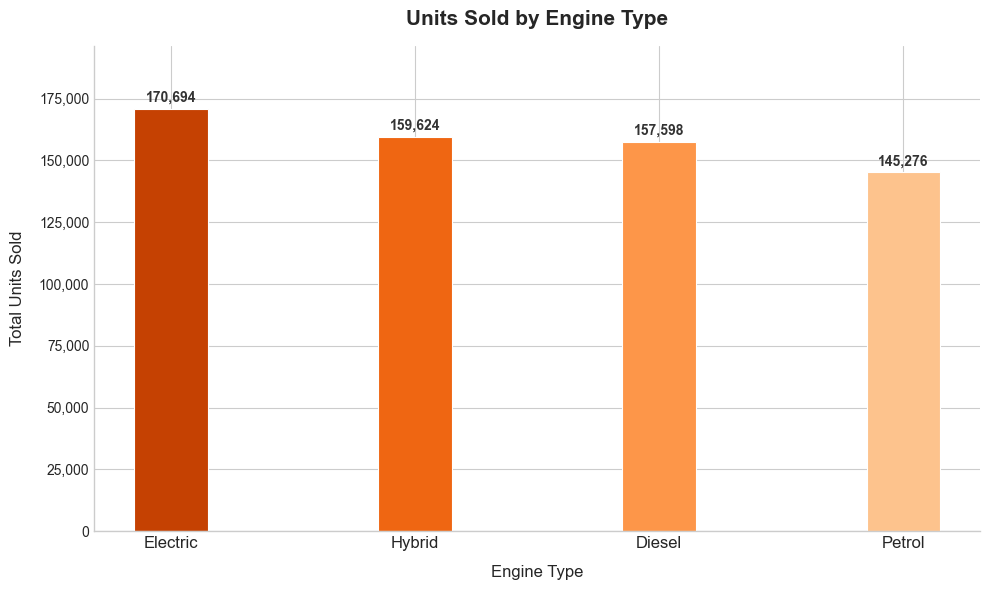

In [24]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- Data (sorted properly) ---
engine_spend = (
    df.groupby("engine_type")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)
x = engine_spend.index
y = engine_spend.values

# --- Style ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Color gradient based on rank
colors = plt.cm.Oranges_r(np.linspace(0.2, 0.7, len(x)))

bars = ax.bar(x, y, color=colors, width=0.3, edgecolor="white", linewidth=0.8)

# --- Value labels on top of each bar ---
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"{height:,}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="#333333"
    )

# --- Axis formatting ---
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f"{val:,.0f}"))
ax.set_ylim(0, y.max() * 1.15)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=10)

# --- Labels & title ---
ax.set_title("Units Sold by Engine Type", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Engine Type", fontsize=12, labelpad=10)
ax.set_ylabel("Total Units Sold", fontsize=12, labelpad=10)

# --- Clean up spines ---
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

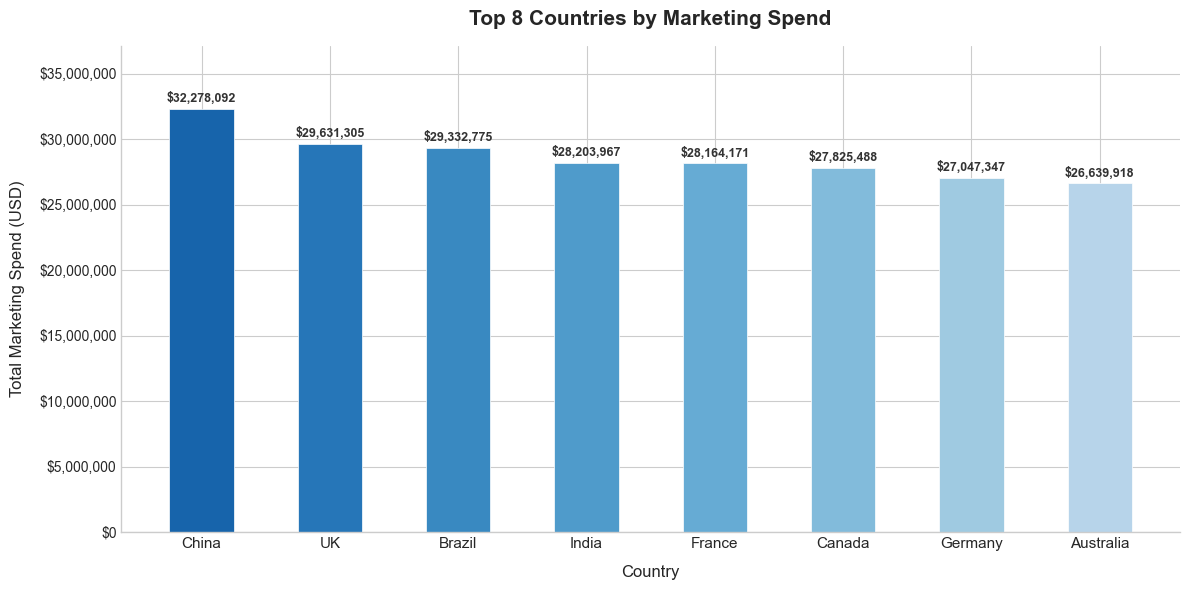

In [68]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- Data (sorted properly) ---
country_spend = (
    df.groupby("country")["marketing_spend_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
)
x = country_spend.index
y = country_spend.values

# --- Style ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

# Color gradient based on rank
colors = plt.cm.Blues_r(np.linspace(0.2, 0.7, len(x)))

bars = ax.bar(x, y, color=colors, width=0.5, edgecolor="white", linewidth=0.5)

# --- Value labels on top of each bar ---
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"${height:,.0f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color="#333333"
    )

# --- Axis formatting ---
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f"${val:,.0f}"))
ax.set_ylim(0, y.max() * 1.15)  # headroom for labels
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=10)

# --- Labels & title ---
ax.set_title("Top 8 Countries by Marketing Spend", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Country", fontsize=12, labelpad=10)
ax.set_ylabel("Total Marketing Spend (USD)", fontsize=12, labelpad=10)

# --- Clean up spines ---
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

[0 1 2 3 4 5 6 7]


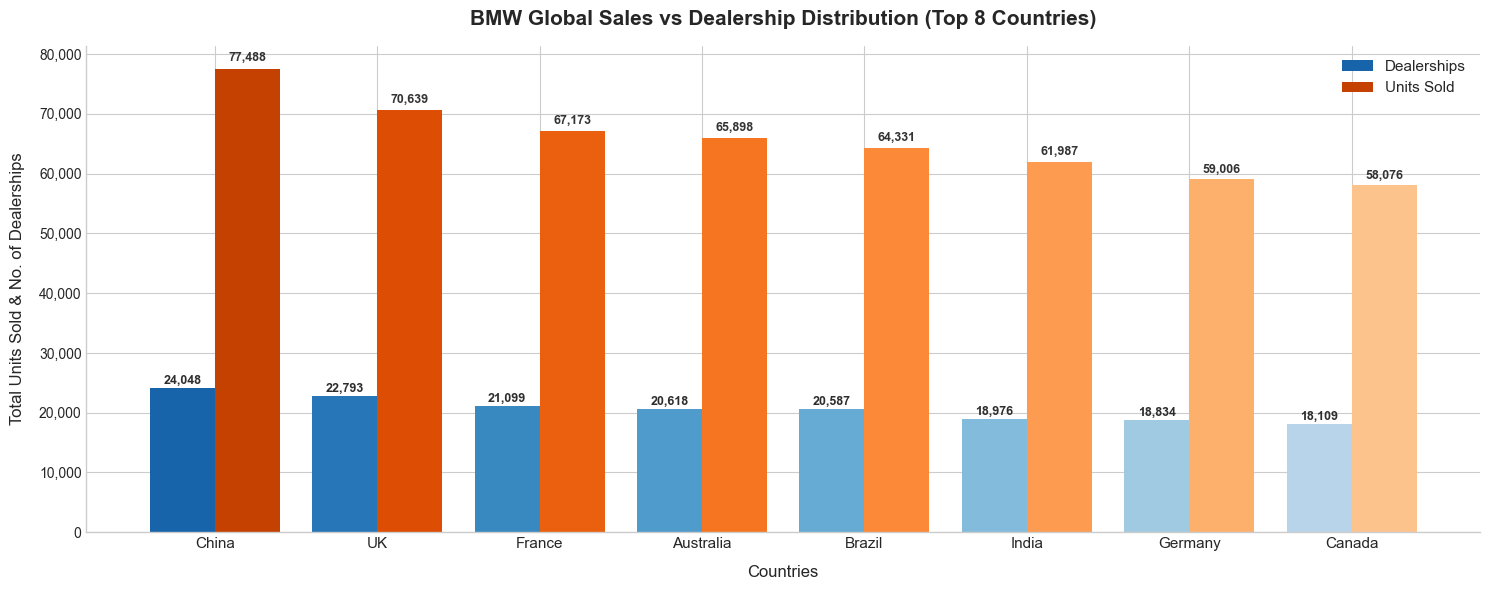

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv("../data/bmw_global_sales_dataset.csv")

# --- Data: split into two periods ---

dealerships  = df.groupby("country")["dealership_count"].sum().sort_values(ascending=False).head(8)
units_Sold = df.groupby('country')['units_sold'].sum().sort_values(ascending=False).head(8)

countries = dealerships.index.tolist()
x     = np.arange(len(countries))  # x positions for each group
width = 0.4                           # width of each bar

colors1 = plt.cm.Blues_r(np.linspace(0.2, 0.7, len(x)))
colors2 = plt.cm.Oranges_r(np.linspace(0.2, 0.7, len(x)))

# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 6))

bars1 = ax.bar(x - width/2, dealerships.values,  width, label='Dealerships', color=colors1)
bars2 = ax.bar(x + width/2, units_Sold.values, width, label='Units Sold', color=colors2)

for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"{height:,.0f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color="#2E2E2E"
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"{height:,.0f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color="#333333"
    )

# --- Axis formatting ---
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f"{val:,.0f}"))
ax.set_xticks(x)
ax.set_xticklabels(countries)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=10)

#--- Labels & title ---
ax.set_title("BMW Global Sales vs Dealership Distribution (Top 8 Countries)", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Countries", fontsize=12, labelpad=10)
ax.set_ylabel("Total Units Sold & No. of Dealerships", fontsize=12, labelpad=10)

# --- Clean up spines ---
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(loc='upper right', fontsize=11)


plt.tight_layout()
plt.show()

[0 1 2 3]


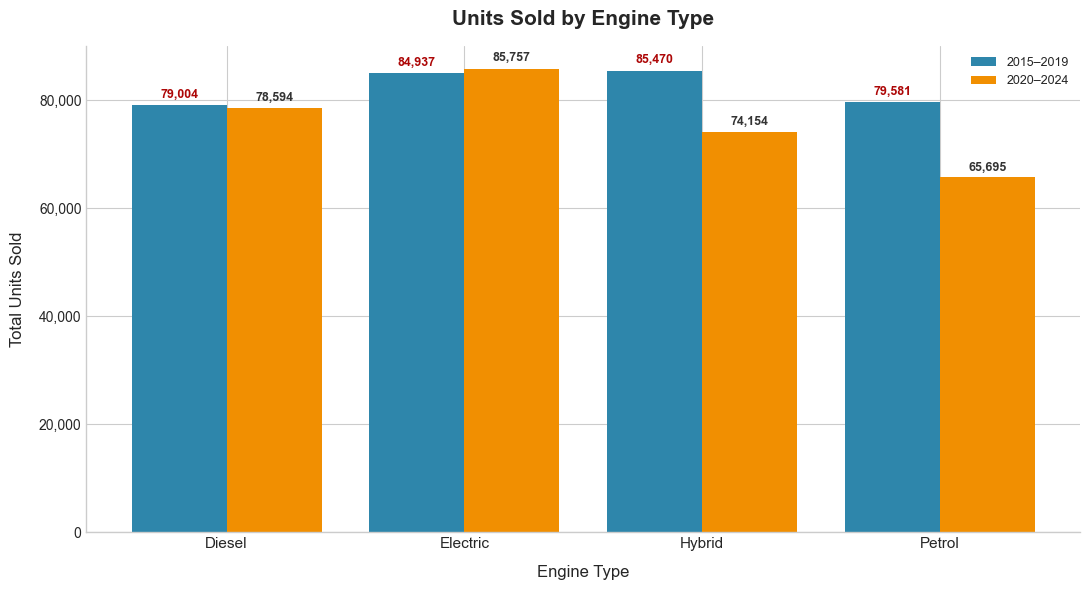

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- Data: split into two periods ---
early  = df[df['year'] <= 2019].groupby('engine_type')['units_sold'].sum()
recent = df[df['year'] >= 2020].groupby('engine_type')['units_sold'].sum()

engine_types = early.index.tolist()
x     = np.arange(len(engine_types))  # x positions for each group
width = 0.4                           # width of each bar

print(  x)

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, early.values,  width, label='2015–2019', color='#2E86AB')
bars2 = ax.bar(x + width/2, recent.values, width, label='2020–2024', color='#F18F01')

for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"{height:,.0f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color="#AD0707"
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"{height:,.0f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color="#333333"
    )



    # --- Axis formatting ---
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f"{val:,.0f}"))
ax.set_xticks(x)
ax.set_xticklabels(engine_types)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=10)

#--- Labels & title ---
ax.set_title("Units Sold by Engine Type", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Engine Type", fontsize=12, labelpad=10)
ax.set_ylabel("Total Units Sold", fontsize=12, labelpad=10)

# --- Clean up spines ---
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

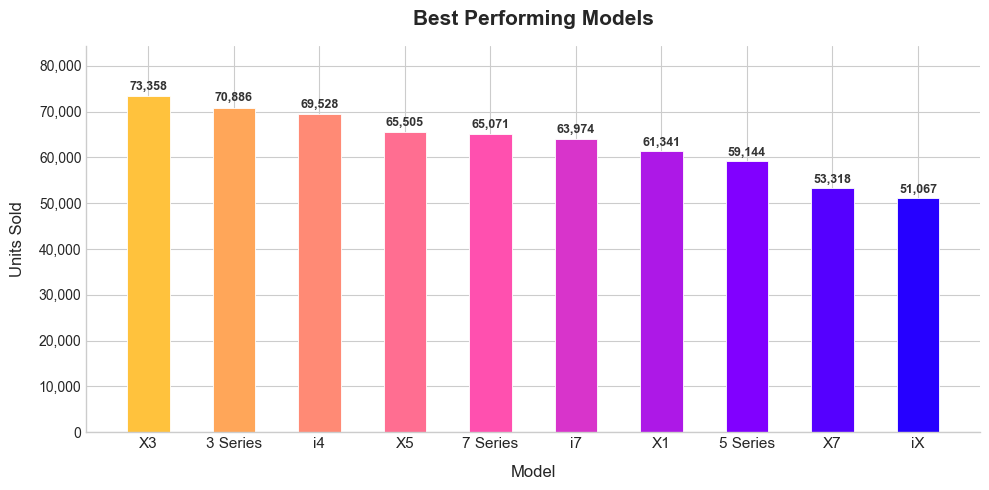

In [55]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- Data (sorted properly) ---
models_sold = (
    df.groupby("model")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)
x = models_sold.index
y = models_sold.values

# --- Style ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))

# Color gradient based on rank
colors = plt.cm.gnuplot2_r(np.linspace(0.2, 0.7, len(x)))

bars = ax.bar(x, y, color=colors, width=0.5, edgecolor="white", linewidth=0.6)

# --- Value labels on top of each bar ---
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"{height:,.0f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color="#333333"
    )

# --- Axis formatting ---
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f"{val:,.0f}"))
ax.set_ylim(0, y.max() * 1.15)  # headroom for labels
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=10)

# --- Labels & title ---
ax.set_title("Best Performing Models", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Model", fontsize=12, labelpad=10)
ax.set_ylabel("Units Sold", fontsize=12, labelpad=10)

# --- Clean up spines ---
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

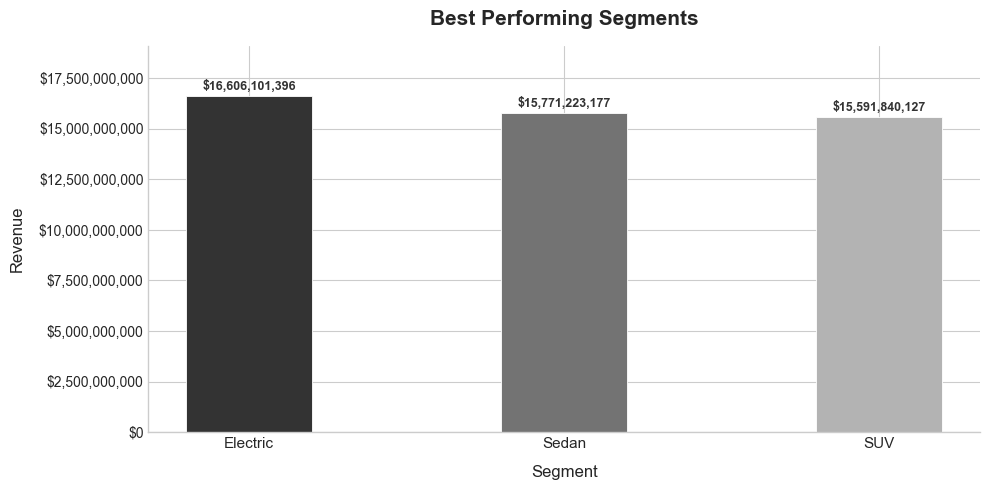

In [64]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- Data (sorted properly) ---
models_sold = (
    df.groupby("segment")["revenue"]
    .sum().sort_values(ascending=False)

)
x = models_sold.index
y = models_sold.values

# --- Style ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))

# Color gradient based on rank
colors = plt.cm.grey(np.linspace(0.2, 0.7, len(x)))

bars = ax.bar(x, y, color=colors, width=0.4, edgecolor="white", linewidth=0.6)

# --- Value labels on top of each bar ---
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"${height:,.0f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color="#333333"
    )

# --- Axis formatting ---
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f"${val:,.0f}"))
ax.set_ylim(0, y.max() * 1.15)  # headroom for labels
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=10)

# --- Labels & title ---
ax.set_title("Best Performing Segments", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Segment", fontsize=12, labelpad=10)
ax.set_ylabel("Revenue", fontsize=12, labelpad=10)

# --- Clean up spines ---
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()